# 01 · Data Cleaning & Preprocessing

Prepares the raw operational export of an **on-demand delivery platform** for analysis.

> **Note:** the dataset is fully **synthetic** (generated by `scripts/generate_synthetic_data.py`) and mimics a realistic raw export — including duplicates, missing values, placeholder markers, and logging artifacts.

**Steps**
1. Load raw data and standardize the schema
2. Remove duplicates and redundant columns
3. Reconstruct missing order statuses with an evidence-based threshold
4. Detect outliers (IQR + business logic) and quarantine suspicious orders
5. Export the clean dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load raw data

In [2]:
df = pd.read_csv("../data/synthetic_delivery_data_raw.csv.gz", compression="gzip")

In [3]:
df.head()

,Date,OrderID,Final_Status,StoreID,City,DriverID,ConfirmationHour,CancelHour,FirstAssignDu,LastAssignDU,Diff_AssignTime_Minutes,Queue_DU,SourceArrival_DU,PickUp_DU,DestinationArrival_DU,Operation_DU,DistanceVendorToCustomer,DistanceBikerToVendor
0,2025-06-18,5720872,DeliveredWithDelay,30588,Istanbul,869,12,**,0,2,2,2,13.0,0.0,12.0,27.0,5196,1707.0
1,2025-06-18,5506901,Delivered,69169,Ankara,769,20,**,1,9,8,9,14.0,1.0,4.0,28.0,1638,NaN
2,2025-06-09,5318498,DeliveredWithDelay,7625,Ankara,573,20,**,1,15,14,15,7.0,6.0,1.0,29.0,3076,2514.0
3,2025-06-19,5099681,DeliveredWithDelay,8118,Ankara,310,13,**,2,4,2,4,7.0,4.0,12.0,27.0,4492,3343.0
4,2025-06-08,5353680,Delivered,60083,Istanbul,661,19,**,6,6,0,6,14.0,0.0,7.0,27.0,12653,4168.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170060 entries, 0 to 170059
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Date                      170060 non-null  object 
 1   OrderID                   170060 non-null  int64  
 2   Final_Status              168388 non-null  object 
 3   StoreID                   170060 non-null  int64  
 4   City                      170060 non-null  object 
 5   DriverID                  170060 non-null  int64  
 6   ConfirmationHour          170060 non-null  int64  
 7   CancelHour                170060 non-null  object 
 8   FirstAssignDu             170060 non-null  int64  
 9   LastAssignDU              170060 non-null  int64  
 10  Diff_AssignTime_Minutes   170060 non-null  int64  
 11  Queue_DU                  170060 non-null  int64  
 12  SourceArrival_DU          169748 non-null  float64
 13  PickUp_DU                 168062 non-null  f

## 2. Standardize the schema

Raw system column names (`Queue_DU`, `Operation_DU`, …) are renamed to analysis-friendly names, and identifier columns are cast to strings.

In [5]:
# 1. rename - change format
df.columns = df.columns.str.strip() 


rename_map = {
    'Date': 'Order_Date',
    'Operation_DU': 'Total_Cycle_Time',
    'DestinationArrival_DU': 'Transit_To_Customer_Time',
    'DistanceVendorToCustomer': 'Distance_V2C',
    'SourceArrival_DU': 'Travel_To_Vendor_Time',
    'PickUp_DU': 'At_Vendor_Prep_Time',
    'ConfirmationHour': 'Order_Hour',
    'CancelHour': 'Cancel_Hour',
    'Queue_DU': 'Dispatch_Wait_Time',
    'DistanceBikerToVendor': 'Distance_B2V'
}
df.rename(columns=rename_map, inplace=True)


df['OrderID'] = df['OrderID'].astype(str)
df['StoreID'] = df['StoreID'].astype(str)
df['Order_Date'] = df['Order_Date'].astype(str)

## 3. Duplicates

Double-logged events are removed based on full-row equality.

In [6]:
# 2. Check and drop duplicates
initial_rows = len(df)
duplicate_count = df.duplicated().sum()
print(f"The number of duplicates: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicate_count} are deleted!")
else:
    print("There is nothing to be deleted!")

The number of duplicates: 60
60 are deleted!


## 4. Redundant columns

`LastAssignDU` should equal `Dispatch_Wait_Time` (`Queue_DU`); after verifying, we drop it.

In [7]:
# 3. Check whether Dispatch_Wait_Time and LastAssignDU are the same...

mismatch_count = (df['Dispatch_Wait_Time'] != df['LastAssignDU']).sum()
print(f"Number of mismatches between the two columns: {mismatch_count}")

# delete LastAssignDU
df.drop(columns=['LastAssignDU'], inplace=True)

Number of mismatches between the two columns: 0


## 5. Status reconstruction

About 1% of orders lose their `Final_Status` due to late status synchronization. Before imputing, we find an **empirical delay threshold** from the distribution of delivery times.

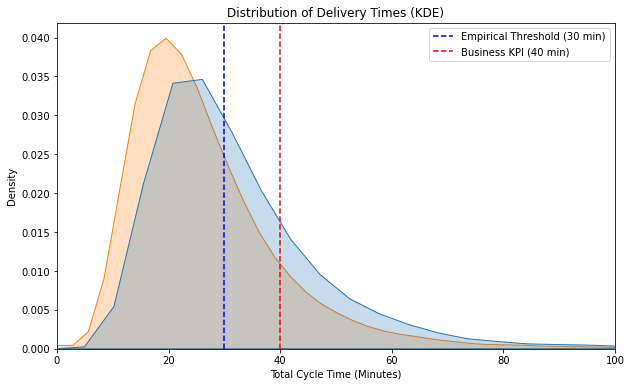

In [8]:
# 4. Filling missing data in Final_status column
# remain Final_Status without change

df['Operational_Status'] = df['Final_Status'].copy()

# finding real threshold based on existing data (distribution)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Operational_Status'].isin(['Delivered', 'DeliveredWithDelay'])], 
            x='Total_Cycle_Time', hue='Operational_Status', fill=True, common_norm=False)

plt.axvline(30, color='blue', linestyle='--', label='Empirical Threshold (30 min)')
plt.axvline(40, color='red', linestyle='--', label='Business KPI (40 min)')
plt.title('Distribution of Delivery Times (KDE)')
plt.xlabel('Total Cycle Time (Minutes)')
plt.xlim(0, 100)
plt.legend()
plt.show()



In [9]:
# real threshold=30 min for labeling (before 30 min ----> delivered/ later than 30 min ----->DeliveredWithDelay or Return)
# assess the diference between DeliveredWithDelay or Return

known_data = df[df['Final_Status'].isin(['Delivered','DeliveredWithDelay', 'Returned'])].copy()

stats = known_data.groupby('Final_Status').agg({
    'Total_Cycle_Time': 'mean',
    'Transit_To_Customer_Time': 'mean',
    'Distance_V2C': 'mean'
}).reset_index()

stats['Transit_Ratio'] = stats['Transit_To_Customer_Time'] / stats['Total_Cycle_Time']

print(stats)

avg_returned_time = stats[stats['Final_Status'] == 'Returned']['Total_Cycle_Time'].values[0]
avg_delivered_time = stats[stats['Final_Status'] == 'Delivered']['Total_Cycle_Time'].values[0]

         Final_Status  Total_Cycle_Time  Transit_To_Customer_Time  \
0           Delivered         27.363971                  9.100866   
1  DeliveredWithDelay         32.594862                 11.379483   
2            Returned         39.398551                 20.873188   

   Distance_V2C  Transit_Ratio  
0   3410.297793       0.332586  
1   3389.723086       0.349119  
2   3460.992754       0.529796  


In [10]:
delivered_df = df[df['Final_Status'] == 'Delivered']
total_delivered_count = len(delivered_df)

delivered_under_30_count = len(delivered_df[delivered_df['Total_Cycle_Time'] <= 30])

ratio = (delivered_under_30_count / total_delivered_count) * 100

print(f"The number of delivered orders: {total_delivered_count}")
print(f"the number of delivered orders(under 30 min): {delivered_under_30_count}")
print(f" ratio: {ratio:.2f}%")

The number of delivered orders: 110701
the number of delivered orders(under 30 min): 78075
 ratio: 70.53%


In [11]:
delivered_delay_df = df[df['Final_Status'] == 'DeliveredWithDelay']
total_delivered_count = len(delivered_delay_df)

delivered_more_30_count = len(delivered_delay_df[(delivered_delay_df['Total_Cycle_Time'] > 30)&((delivered_delay_df['Total_Cycle_Time'] < 90))])

ratio = (delivered_more_30_count / total_delivered_count) * 100

print(f"The number of delivered orders:{total_delivered_count}")
print(f"The number of delivered orders(more than 30 min): {delivered_more_30_count}")
print(f"ratio: {ratio:.2f}%")

The number of delivered orders:56245
The number of delivered orders(more than 30 min): 23871
ratio: 42.44%


In [12]:

delayed_stats = df[df['Operational_Status'] == 'DeliveredWithDelay'][['Total_Cycle_Time', 'Distance_V2C']].describe()

print(delayed_stats)

delay_rate = (len(df[df['Operational_Status'] == 'DeliveredWithDelay']) / len(df)) * 100
print(delay_rate)

       Total_Cycle_Time  Distance_V2C
count      56245.000000  56245.000000
mean          32.594862   3389.723086
std           18.892312   2315.136424
min            6.000000    205.000000
25%           21.000000   1842.000000
50%           28.000000   2801.000000
75%           39.000000   4252.000000
max         1045.000000  34043.000000
33.08529411764706


In [13]:
# Returned
returned_stats = df[df['Operational_Status'] == 'Returned'][['Total_Cycle_Time', 'Distance_V2C']].describe()


print(returned_stats)

returned_rate = (len(df[df['Operational_Status'] == 'Returned']) / len(df)) * 100
print(returned_rate)

       Total_Cycle_Time  Distance_V2C
count        276.000000    276.000000
mean          39.398551   3460.992754
std           19.828002   2303.677458
min            5.000000    557.000000
25%           26.000000   1899.250000
50%           35.000000   3008.000000
75%           47.000000   4488.250000
max          161.000000  20419.000000
0.1623529411764706


### Business-logic labeler

Missing statuses are reconstructed with rules that combine cycle time, cancellation markers, and implied speed. Physically impossible orders (cycle < 2 min or > 3 h on a `Delivered` label) are flagged as `Anomaly`.

In [14]:
df['Original_Status']=df['Final_Status']

def advanced_labeler(row):
    if pd.notna(row['Original_Status']):
        if row['Original_Status'] == 'Delivered' and (row['Total_Cycle_Time'] < 2 or row['Total_Cycle_Time'] > 180):
            return 'Anomaly'
        return row['Original_Status']
    
    if pd.isna(row['Total_Cycle_Time']):
        return 'Canceled' if row['Cancel_Hour'] != '**' else 'Incomplete_Data'
    
    if row['Total_Cycle_Time'] < 2: return 'Anomaly'
    if row['Total_Cycle_Time'] <= 30: return 'Delivered'
    
    speed = row['Distance_V2C'] / (row['Transit_To_Customer_Time'] if row['Transit_To_Customer_Time'] > 0 else 1)
    if row['Total_Cycle_Time'] > 80 and speed < 150:
        return 'Returned'
    return 'DeliveredWithDelay'

df['Operational_Status'] = df.apply(advanced_labeler, axis=1)

### Status distribution after reconstruction

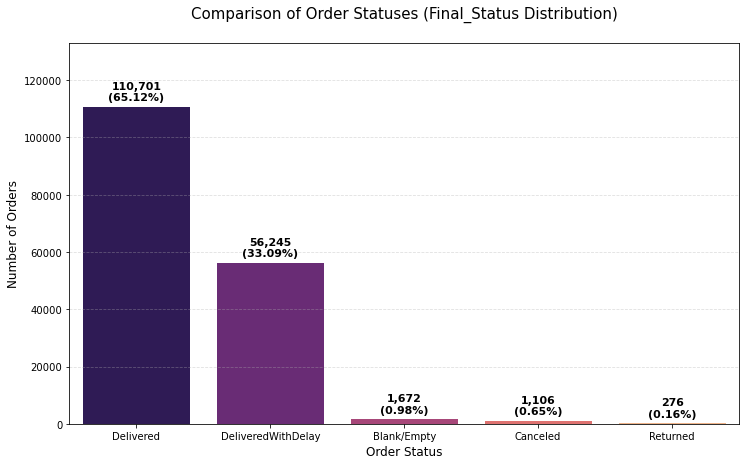

In [15]:

status_series = df['Final_Status'].fillna('Blank/Empty')
counts = status_series.value_counts()
percentages = status_series.value_counts(normalize=True) * 100

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=counts.index, y=counts.values, palette='magma')

for i, p in enumerate(ax.patches):
    count = counts.values[i]
    pct = percentages.values[i]
    ax.annotate(f'{int(count):,}\n({pct:.2f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 15), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Comparison of Order Statuses (Final_Status Distribution)', fontsize=15, pad=25)
plt.ylabel('Number of Orders', fontsize=12)
plt.xlabel('Order Status', fontsize=12)
plt.ylim(0, counts.max() * 1.2) 
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig('status_distribution.png')
plt.show()

## 6. Outlier analysis (IQR + business thresholds)

IQR Results: Q1=19.0, Q3=35.0, IQR=16.0
IQR Bounds: [-5.0, 59.0]
Total rows flagged as outliers by IQR: 7447 (4.38%)
Delivered orders > 3 hours (Suspicious): 166

Final Status counts (after recovery):
Delivered             110701
DeliveredWithDelay     56245
NaN                     1672
Canceled                1106
Returned                 276
Name: Final_Status, dtype: int64


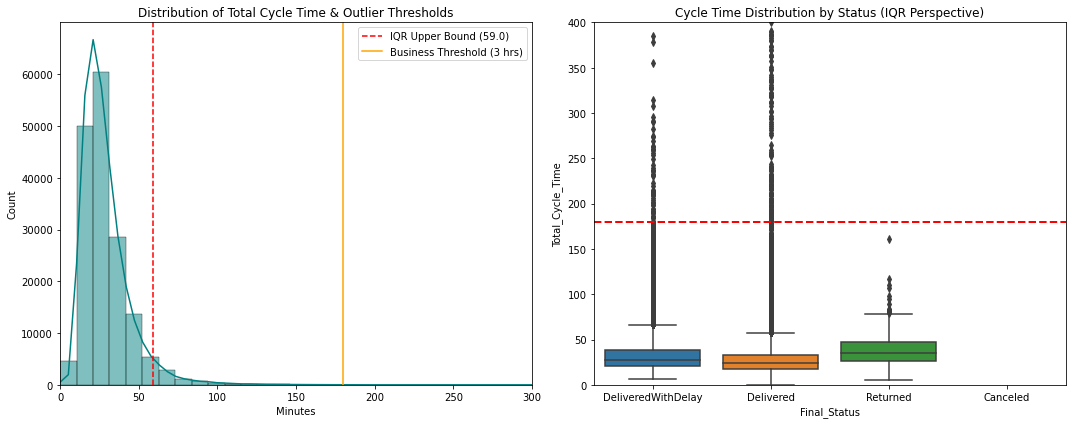

In [16]:
#outliers -----iqr? hybrid?
# 4. Outlier Analysis: IQR Method
Q1 = df['Total_Cycle_Time'].quantile(0.25)
Q3 = df['Total_Cycle_Time'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Total_Cycle_Time'] > upper_iqr) | (df['Total_Cycle_Time'] < lower_iqr)]

# 5. Visualization for Decision Making
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram/KDE with IQR and Business Thresholds
plt.subplot(1, 2, 1)
sns.histplot(df['Total_Cycle_Time'], bins=100, kde=True, color='teal')
plt.axvline(upper_iqr, color='red', linestyle='--', label=f'IQR Upper Bound ({upper_iqr:.1f})')
plt.axvline(180, color='orange', linestyle='-', label='Business Threshold (3 hrs)')
plt.title('Distribution of Total Cycle Time & Outlier Thresholds')
plt.xlabel('Minutes')
plt.xlim(0, 300)
plt.legend()

# Subplot 2: Boxplot per Final_Status
plt.subplot(1, 2, 2)
sns.boxplot(x='Final_Status', y='Total_Cycle_Time', data=df)
plt.title('Cycle Time Distribution by Status (IQR Perspective)')
plt.ylim(0, 400)
plt.axhline(180, color='red', linestyle='--', linewidth=2, label='Anomaly Threshold (180 min)')
plt.tight_layout()
plt.savefig('outlier_analysis_plot.png')


# Summary for the user
print(f"IQR Results: Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"IQR Bounds: [{lower_iqr}, {upper_iqr}]")
print(f"Total rows flagged as outliers by IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

# Specific check for extreme outliers (> 3 hours)
extreme_del = df[(df['Total_Cycle_Time'] > 180) & (df['Final_Status'] == 'Delivered')]
print(f"Delivered orders > 3 hours (Suspicious): {len(extreme_del)}")

# Final Status Check
print("\nFinal Status counts (after recovery):")
print(df['Final_Status'].value_counts(dropna=False))

## 7. Export

Clean operational rows go to `data/operational_data_clean.csv`; anomalous rows are quarantined in `data/suspicious_orders.csv` for auditing rather than silently dropped.

In [17]:
# last method for outliers
df_operational = df[df['Operational_Status'] != 'Anomaly'].copy()

df_suspicious = df[df['Operational_Status'] == 'Anomaly'].copy()

# Save csv files
df_operational.to_csv('../data/operational_data_clean.csv', index=False, encoding='utf-8-sig')
df_suspicious.to_csv('../data/suspicious_orders.csv', index=False, encoding='utf-8-sig')